In [3]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans 
import pandas as pd

In [2]:
iris = load_iris()

In [10]:
# X = pd.DataFrame(iris.data)
# X.columns = iris.feature_names
X = iris.data
y = iris.target

<Axes: >

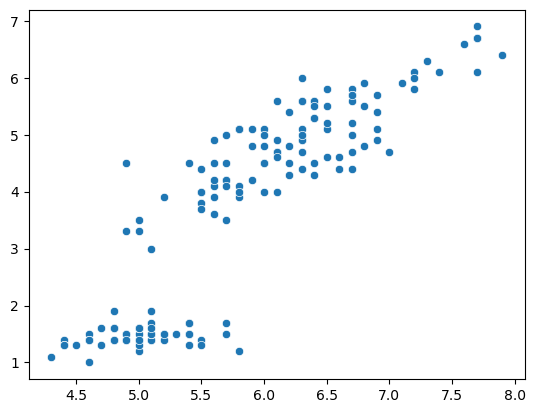

In [12]:
#Visualize
sns.scatterplot(x=X[:,0],y=X[:,2])

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
#elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

<Axes: >

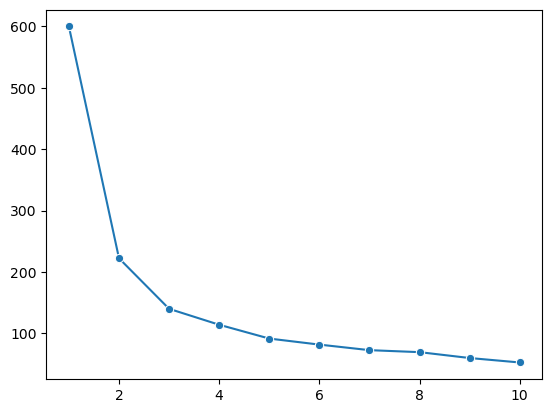

In [22]:
sns.lineplot(x=range(1,11),y=wcss,marker = "o")

<Axes: >

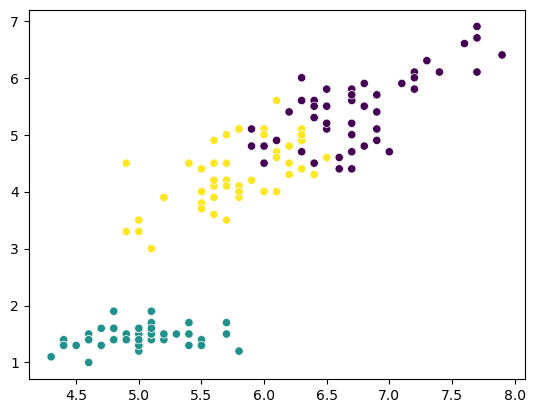

In [23]:
kmeans = KMeans(n_clusters= 3 )
labels = kmeans.fit_predict(X_scaled)
sns.scatterplot(x=X[:,0],y=X[:,2],c=labels)

In [ ]:
#optional - dimensionality reductio using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)

In [25]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

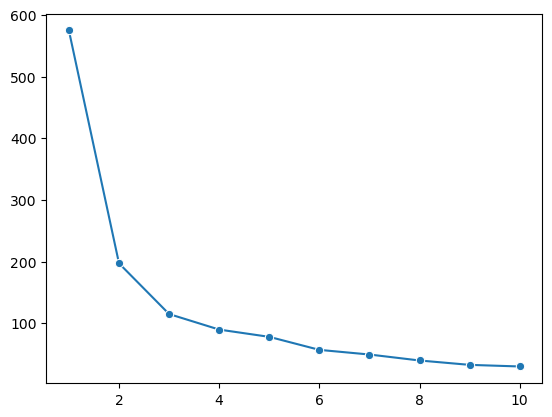

In [26]:
sns.lineplot(x=range(1,11),y=wcss,marker = "o")

<Axes: >

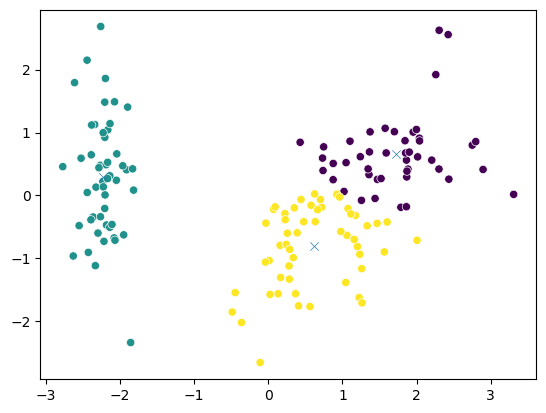

In [31]:
kmeans = KMeans(n_clusters= 3 )
labels = kmeans.fit_predict(pca_data)
sns.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker = "x")